# DIAGNOSTIC: Why is BAND-NKN Failing?

**Your results show:**
- All configs lose money badly
- 1,535+ trades with high leverage (massive overtrading)
- Only 12 trades with 2x leverage
- -53% to -97.8% returns

**Possible causes:**
1. Correlation broke down during your data period
2. Window too long (6 months might be stale)
3. Z-entry threshold too low (1.0 enters too often)
4. Wrong data period (maybe trending instead of mean-reverting)
5. BAND-NKN just isn't a good pair anymore

Let's investigate!

In [ ]:
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.regression.linear_model import OLS

# Collect data (reuse if you have it)
collector = ccxt.binance({'enableRateLimit': True, 'options': {'defaultType': 'future'}})

def fetch_data(symbol, days=400):
    from datetime import datetime, timedelta
    print(f"Fetching {symbol}...")
    all_data = []
    since = int((datetime.now() - timedelta(days=days)).timestamp() * 1000)
    
    while True:
        try:
            ohlcv = collector.fetch_ohlcv(symbol, '1h', since, 1500)
            if not ohlcv:
                break
            df = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
            df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
            df.set_index('timestamp', inplace=True)
            all_data.append(df)
            since = int(df.index[-1].timestamp() * 1000) + 3600000
            if df.index[-1] >= datetime.now():
                break
        except:
            break
    
    if all_data:
        combined = pd.concat(all_data)
        combined = combined[~combined.index.duplicated(keep='first')]
        print(f"  Got {len(combined)} candles")
        return combined
    return None

data_band = fetch_data('BAND/USDT:USDT', 400)
data_nkn = fetch_data('NKN/USDT:USDT', 400)

merged = pd.DataFrame({
    'BAND': data_band['close'],
    'NKN': data_nkn['close']
}).dropna()

print(f"\nData period: {merged.index[0]} to {merged.index[-1]}")
print(f"Total hours: {len(merged)}")

Fetching BAND/USDT:USDT...
  Got 9600 candles
Fetching NKN/USDT:USDT...
  Got 9600 candles

Data period: 2025-02-17 06:00:00 to 2026-03-24 05:00:00
Total hours: 9600


## 1. Check Correlation Stability

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/correlation_stability.png'

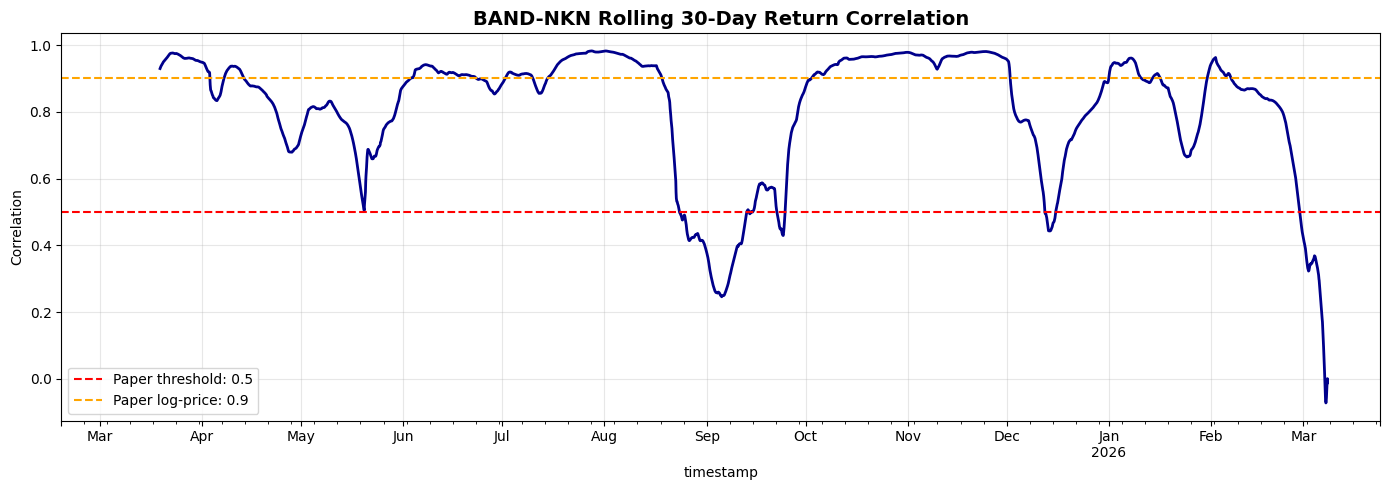

In [ ]:
# Rolling correlation
window = 720  # 30 days
rolling_corr = merged['BAND'].rolling(window).corr(merged['NKN'])

plt.figure(figsize=(14, 5))
rolling_corr.plot(linewidth=2, color='darkblue')
plt.axhline(y=0.5, color='red', linestyle='--', label='Paper threshold: 0.5')
plt.axhline(y=0.9, color='orange', linestyle='--', label='Paper log-price: 0.9')
plt.title('BAND-NKN Rolling 30-Day Return Correlation', fontsize=14, fontweight='bold')
plt.ylabel('Correlation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('correlation_stability.png', dpi=150)
plt.show()

print(f"Current correlation: {merged['BAND'].corr(merged['NKN']):.3f}")
print(f"Mean rolling corr: {rolling_corr.mean():.3f}")
print(f"Min rolling corr: {rolling_corr.min():.3f}")
print(f"\n⚠️ If correlation dropped below 0.5, the pair broke down!")

## 2. Check Spread Behavior

In [ ]:
# Calculate spread with fixed window
log_band = np.log(merged['BAND'])
log_nkn = np.log(merged['NKN'])

# Simple regression on full period
X = np.column_stack([np.ones(len(log_nkn)), log_nkn])
model = OLS(log_band, X)
results = model.fit()
beta = results.params[1]
alpha = results.params[0]

spread = log_band - alpha - beta * log_nkn
z_score = (spread - spread.mean()) / spread.std()

print(f"Beta (hedge ratio): {beta:.4f}")
print(f"Spread std: {spread.std():.6f}")

# ADF test
adf_result = adfuller(spread, maxlag=1)
print(f"\nADF test:")
print(f"  Statistic: {adf_result[0]:.4f}")
print(f"  P-value: {adf_result[1]:.4f}")
print(f"  Cointegrated: {'YES' if adf_result[1] < 0.05 else 'NO'}")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Spread
spread.plot(ax=axes[0], linewidth=1, color='black', alpha=0.7)
axes[0].axhline(y=0, color='green', linestyle='-', alpha=0.5)
axes[0].set_title('Spread (residuals)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Spread')
axes[0].grid(True, alpha=0.3)

# Z-score
z_score.plot(ax=axes[1], linewidth=1, color='darkred', alpha=0.7)
axes[1].axhline(y=1.0, color='red', linestyle='--', label='Entry: ±1.0')
axes[1].axhline(y=-1.0, color='red', linestyle='--')
axes[1].axhline(y=0, color='green', linestyle='-', alpha=0.5, label='Exit: 0')
axes[1].set_title('Z-Score', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Z-Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('spread_analysis.png', dpi=150)
plt.show()

# Count signals
entry_signals = (z_score.abs() > 1.0).sum()
print(f"\nEntry signals (|z| > 1.0): {entry_signals}")
print(f"That's {entry_signals / len(z_score) * 100:.1f}% of the time!")
print(f"\n⚠️ If >20%, you're trading TOO OFTEN (overtrading!)")

## 3. Check If Spread Is Mean-Reverting

In [ ]:
# Half-life of mean reversion
spread_lag = spread.shift(1).dropna()
spread_diff = spread.diff().dropna()
aligned = pd.DataFrame({'lag': spread_lag, 'diff': spread_diff}).dropna()

model = OLS(aligned['diff'], aligned['lag'])
result = model.fit()
theta = result.params[0]

if theta < 0:
    half_life = -np.log(2) / theta
    print(f"Half-life: {half_life:.1f} hours ({half_life/24:.1f} days)")
    
    if half_life < 24:
        print("  ✓ Fast mean reversion (< 1 day)")
    elif half_life < 168:
        print("  ⚠️ Slow mean reversion (1-7 days)")
    else:
        print("  ✗ Very slow/no mean reversion (> 7 days) - BAD!")
else:
    print("  ✗ NO MEAN REVERSION - Spread is trending!")
    print("     This pair should NOT be traded!")

## 4. Test Alternative Pairs

Let's test the OTHER recommended pairs to see if they work better

In [ ]:
# Test ANKR-ONT (paper's best: Sharpe 3.44)
print("Testing ANKR-ONT (paper Sharpe: 3.44)...")

data_ankr = fetch_data('ANKR/USDT:USDT', 400)
data_ont = fetch_data('ONT/USDT:USDT', 400)

if data_ankr is not None and data_ont is not None:
    merged2 = pd.DataFrame({
        'ANKR': data_ankr['close'],
        'ONT': data_ont['close']
    }).dropna()
    
    # Quick correlation check
    corr = merged2['ANKR'].corr(merged2['ONT'])
    log_corr = np.log(merged2['ANKR']).corr(np.log(merged2['ONT']))
    
    print(f"  Return correlation: {corr:.3f}")
    print(f"  Log-price correlation: {log_corr:.3f}")
    
    # ADF test
    log_ankr = np.log(merged2['ANKR'])
    log_ont = np.log(merged2['ONT'])
    X = np.column_stack([np.ones(len(log_ont)), log_ont])
    model = OLS(log_ankr, X)
    results = model.fit()
    spread2 = results.resid
    
    adf2 = adfuller(spread2, maxlag=1)
    print(f"  ADF p-value: {adf2[1]:.4f}")
    print(f"  Cointegrated: {'YES' if adf2[1] < 0.05 else 'NO'}")
    
    if corr > 0.5 and log_corr > 0.9:
        print("  ✓ ANKR-ONT passes correlation filters!")
    else:
        print("  ✗ ANKR-ONT also failing")

## 5. Recommendations Based on Diagnostics

Run the cells above and check:

### **If correlation < 0.5:**
→ **STOP!** Pair has broken down. Don't trade it.

### **If NOT cointegrated (p-value > 0.05):**
→ Still tradable (per paper Section 6.5) but riskier

### **If entry signals > 20% of time:**
→ **Z-entry threshold too low!** Try 1.5 or 2.0 instead of 1.0

### **If half-life > 7 days:**
→ **Too slow!** Don't trade this pair

### **If spread is trending (theta > 0):**
→ **NO mean reversion!** Abandon this pair

### **Next steps:**
1. Run diagnostics on BAND-NKN
2. If it fails, try ANKR-ONT or CTSI-CHR
3. Use **higher Z-entry** (1.5-2.0) to reduce overtrading
4. Use **shorter window** (2-3 months instead of 6)
5. Start with **2x leverage maximum**